<a href="https://colab.research.google.com/github/debarghya-IITB/Real_Estate_Price_Prediction_and_Analysis/blob/main/real_estate_price_prediction_and_analysis_mlr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

from statsmodels.graphics.gofplots import qqplot

In [2]:
# Load the dataset
path = 'https://raw.githubusercontent.com/debarghya-IITB/house_data_sets/refs/heads/main/train.csv'
df = pd.read_csv(path)
df.shape

(1460, 81)

In [3]:
df = df.drop(['Id'], axis=1)
df.shape

(1460, 80)

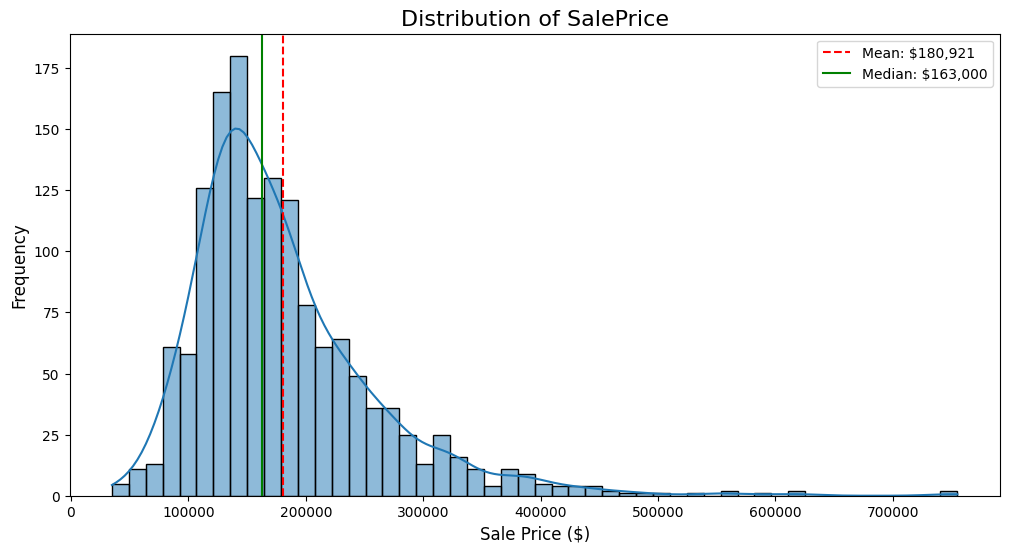

--- Summary Statistics ---
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness: 1.8829


In [4]:
# Set up the matplotlib figure
plt.figure(figsize=(12, 6))

# Plot the histogram and KDE
sns.histplot(df['SalePrice'], kde=True, bins=50)

# Add titles and labels for clarity
plt.title('Distribution of SalePrice', fontsize=16)
plt.xlabel('Sale Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add a vertical line for the mean and median
plt.axvline(df['SalePrice'].mean(), color='r', linestyle='--', label=f"Mean: ${df['SalePrice'].mean():,.0f}")
plt.axvline(df['SalePrice'].median(), color='g', linestyle='-', label=f"Median: ${df['SalePrice'].median():,.0f}")
plt.legend()

# Show the plot
plt.show()

# Print summary statistics and skewness
print("--- Summary Statistics ---")
print(df['SalePrice'].describe())
print(f"\nSkewness: {df['SalePrice'].skew():.4f}")

**Visual Analysis:**


*   The distribution is not symmetrical or bell-shaped (normal).
*   It is clearly **positively skewed** or **right-skewed**. This means there is a long tail on the right side of the distribution, indicating that while most houses are clustered around a certain price range, there are a number of houses that are significantly more expensive.


*   You can see the **mean** (red dashed line) is pulled to the right of the **median** (green solid line). This is a classic characteristic of a right-skewed distribution.

**Statistical Analysis:**
*   **Mean > Median:** The mean price is around `$180,921`, while the median is lower at `$163,000`. This confirms the skewness seen in the plot.
*  **Skewness:** You will get a skewness value of approximately **1.88**. A value close to 0 indicates a symmetrical distribution. A value greater than 1 indicates significant positive skewness.






Linear regression models perform better when the target variable is normally distributed (as it helps to ensure the model's residuals are normally distributed). To correct the skewness, the most common solution is to apply a **log transformation**. We'll use `np.log1p` which computes log(1+x) to avoid issues if a price were ever 0.

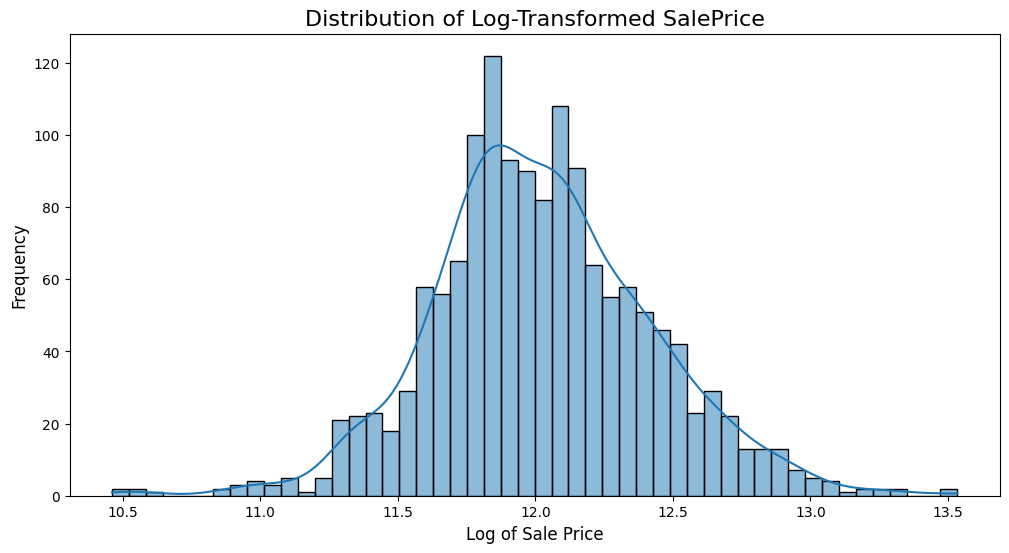

New Skewness: 0.1213


In [5]:
# Apply a log transformation to SalePrice
df['SalePrice_log'] = np.log1p(df['SalePrice'])

# Plot the new distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['SalePrice_log'], kde=True, bins=50)
plt.title('Distribution of Log-Transformed SalePrice', fontsize=16)
plt.xlabel('Log of Sale Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Print the new skewness
print(f"New Skewness: {df['SalePrice_log'].skew():.4f}")

Excellent. The next logical step in EDA is to explore the relationships between the predictor variables (the features) and our target variable, `SalePrice`.

Let's start with the numerical features, as their relationships are often the most direct to analyze in a regression context.

Our plan will be:

1.  **Find the most correlated numerical features:** We'll calculate a correlation matrix to see which numerical variables have the strongest linear relationship with `SalePrice`.

2.  **Visualize these relationships:** We'll create scatter plots for the top-correlated features against our (log-transformed) `SalePrice_log` to visually confirm the trends.

In [6]:
# Calculate the count and percentage of missing values for each column
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

# Combine them into a single DataFrame for a clear report
missing_data = pd.concat([missing_values, missing_percent], axis=1, keys=['Missing Count', 'Missing Percent'])

# Display only the columns that have missing values
print("--- Report of Missing Data ---")
print(missing_data[missing_data['Missing Count'] > 0])

--- Report of Missing Data ---
              Missing Count  Missing Percent
PoolQC                 1453        99.520548
MiscFeature            1406        96.301370
Alley                  1369        93.767123
Fence                  1179        80.753425
MasVnrType              872        59.726027
FireplaceQu             690        47.260274
LotFrontage             259        17.739726
GarageYrBlt              81         5.547945
GarageFinish             81         5.547945
GarageQual               81         5.547945
GarageCond               81         5.547945
GarageType               81         5.547945
BsmtFinType2             38         2.602740
BsmtExposure             38         2.602740
BsmtFinType1             37         2.534247
BsmtQual                 37         2.534247
BsmtCond                 37         2.534247
MasVnrArea                8         0.547945
Electrical                1         0.068493


In [7]:
# Group 1: For these categorical features, NaN means 'None'
for col in ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
            'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
            'MasVnrType']:
    df[col] = df[col].fillna('None')

# Group 2: For these numerical features, NaN means 0
for col in ['GarageYrBlt', 'GarageArea', 'GarageCars',
            'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF',
            'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']:
    df[col] = df[col].fillna(0)

# Group 3: 'LotFrontage' is truly missing. We'll impute with the median LotFrontage of the neighborhood.
# This is a good strategy because houses in the same neighborhood likely have similar lot frontages.
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Group 4: For the few remaining, like 'Electrical', filling with the mode (most common value) is safe.
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# Verify that we have no more missing values
print("\n--- Verification ---")
print(f"Total missing values after imputation: {df.isnull().sum().sum()}")


--- Verification ---
Total missing values after imputation: 0


In [8]:
# Create a mapping for features with a clear quality scale
# Note: 'None' was the value we used for missing data, so it gets a 0.
quality_mapping = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

ordinal_features = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]

for feature in ordinal_features:
    df[feature] = df[feature].map(quality_mapping)
df.shape

(1460, 81)

In [9]:
# Convert all remaining object columns to one-hot encoded columns
# drop_first=True helps to avoid multicollinearity (the dummy variable trap)
df = pd.get_dummies(df, drop_first=True)

print("--- Data Shape After Encoding ---")
print(f"The dataset now has {df.shape[0]} rows and {df.shape[1]} columns.")
print("\n--- Sample of Newly Created Columns ---")
# Example: Check the new columns created from the 'BldgType' feature
for col in list(df.columns):
  df[col] = df[col].astype('float64')
print(df[['BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE']].head())

--- Data Shape After Encoding ---
The dataset now has 1460 rows and 231 columns.

--- Sample of Newly Created Columns ---
   BldgType_2fmCon  BldgType_Duplex  BldgType_Twnhs  BldgType_TwnhsE
0              0.0              0.0             0.0              0.0
1              0.0              0.0             0.0              0.0
2              0.0              0.0             0.0              0.0
3              0.0              0.0             0.0              0.0
4              0.0              0.0             0.0              0.0


In [10]:
df.sample(5)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
1098,50.0,50.0,6000.0,4.0,6.0,1936.0,1950.0,0.0,3.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
113,20.0,74.0,21000.0,6.0,5.0,1953.0,1953.0,184.0,3.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
679,20.0,71.0,9945.0,5.0,5.0,1961.0,1961.0,57.0,3.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
791,80.0,73.0,11333.0,6.0,5.0,1976.0,1976.0,0.0,3.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
256,60.0,64.0,8791.0,6.0,5.0,2003.0,2003.0,0.0,4.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [11]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 231 entries, MSSubClass to SaleCondition_Partial
dtypes: float64(231)
memory usage: 2.6 MB


In [12]:
# Select only numerical columns for the correlation matrix
numerical_cols = df.select_dtypes(include=np.number)
correlations = numerical_cols.corr()

# Get the top 20 features most correlated with SalePrice (excluding SalePrice itself)
# We use .nlargest to get the top values from the 'SalePrice' column of the correlation matrix
k = 21 # number of variables for heatmap
top_corr_features = correlations.nlargest(k, 'SalePrice')['SalePrice'].index
print("--- Top 20 Features Correlated with SalePrice ---")
print(correlations['SalePrice'].nlargest(k))

--- Top 20 Features Correlated with SalePrice ---
SalePrice           1.000000
SalePrice_log       0.948374
OverallQual         0.790982
GrLivArea           0.708624
ExterQual           0.682639
KitchenQual         0.659600
GarageCars          0.640409
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
BsmtQual            0.585207
FullBath            0.560664
TotRmsAbvGrd        0.533723
YearBuilt           0.522897
FireplaceQu         0.520438
YearRemodAdd        0.507101
Foundation_PConc    0.497734
MasVnrArea          0.472614
Fireplaces          0.466929
BsmtFinType1_GLQ    0.434597
HeatingQC           0.427649
Name: SalePrice, dtype: float64


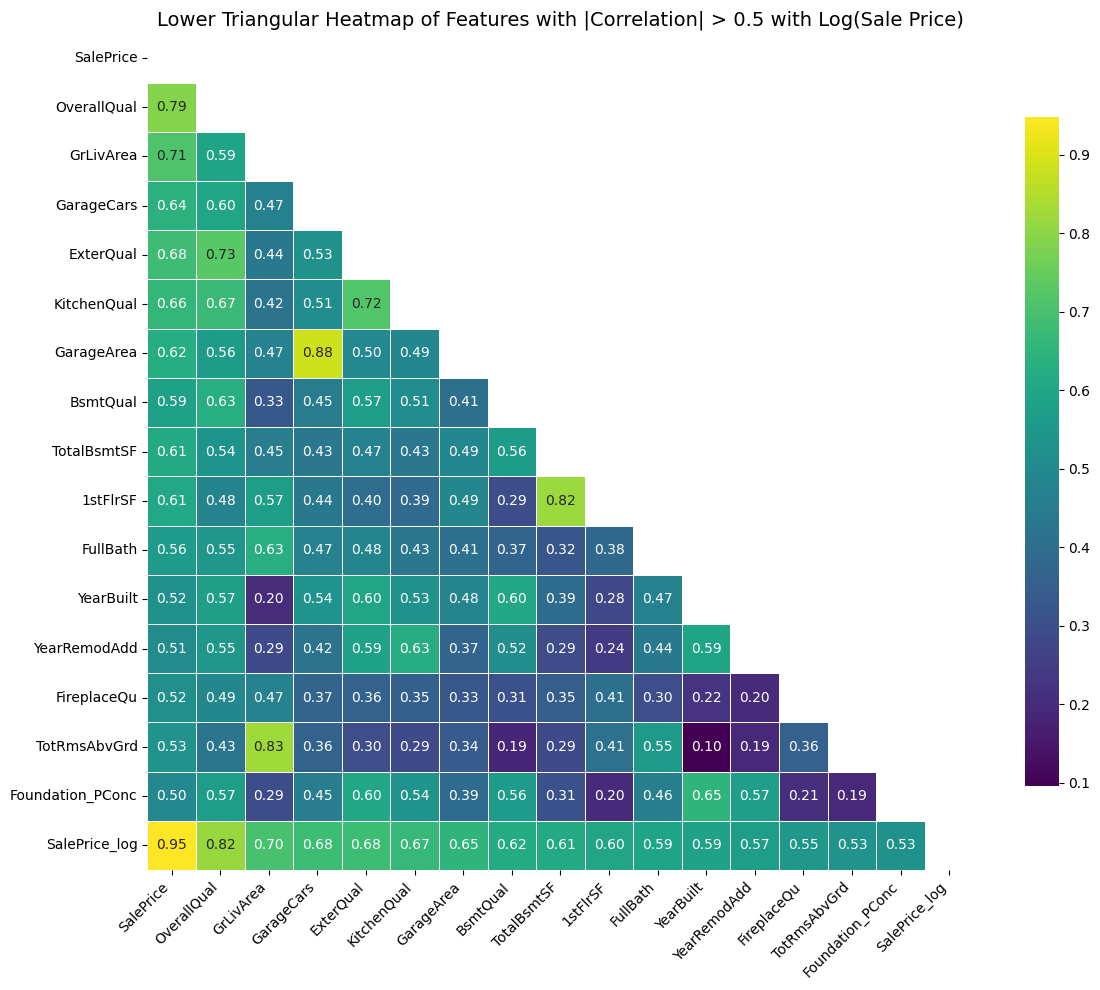

In [13]:
# --- 3. Correlation Filtering and Heatmap Plotting ---

# Calculate correlation with the target ('SalePrice_log')
corr_with_target = df.corr()['SalePrice_log'].sort_values(ascending=False)

# Identify features with absolute correlation > 0.5 (excluding SalePrice_log itself)
high_corr_features = corr_with_target[abs(corr_with_target) > 0.5].index.tolist()

# The target variable must be present in the list for the heatmap
if 'SalePrice_log' in high_corr_features:
    high_corr_features.remove('SalePrice_log')
features_for_heatmap = high_corr_features + ['SalePrice_log']

# Create the final correlation matrix for the selected features
corr_matrix_final = df[features_for_heatmap].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix_final, dtype=bool))

# Plot the lower triangular heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix_final,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Lower Triangular Heatmap of Features with |Correlation| > 0.5 with Log(Sale Price)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
high_corr_features

['SalePrice',
 'OverallQual',
 'GrLivArea',
 'GarageCars',
 'ExterQual',
 'KitchenQual',
 'GarageArea',
 'BsmtQual',
 'TotalBsmtSF',
 '1stFlrSF',
 'FullBath',
 'YearBuilt',
 'YearRemodAdd',
 'FireplaceQu',
 'TotRmsAbvGrd',
 'Foundation_PConc']

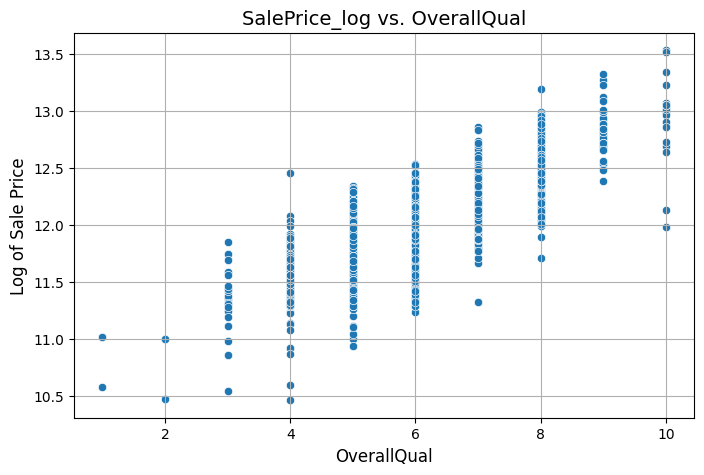

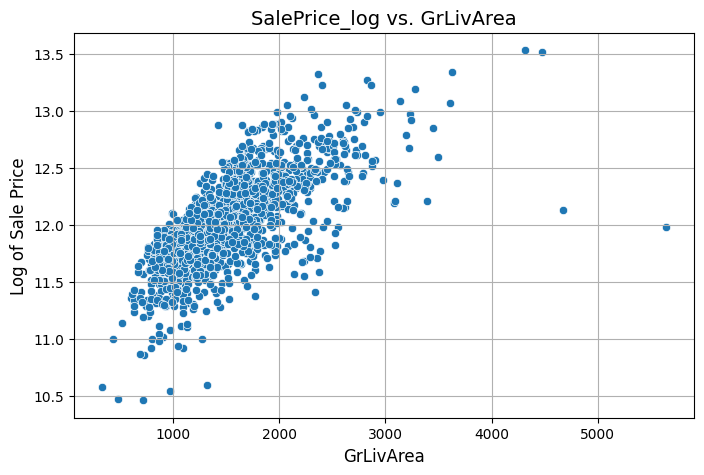

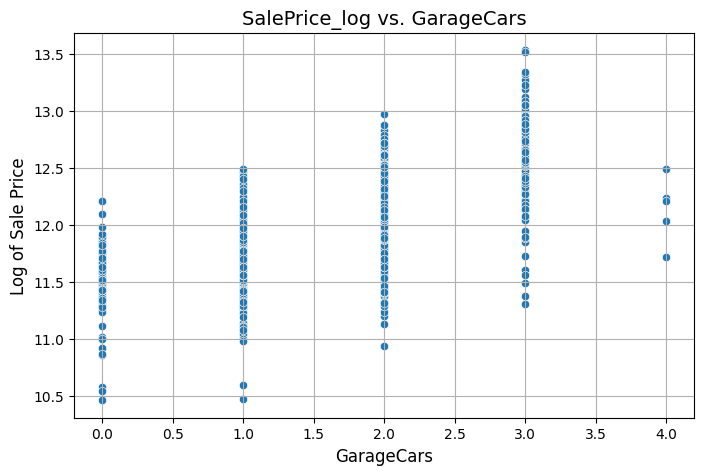

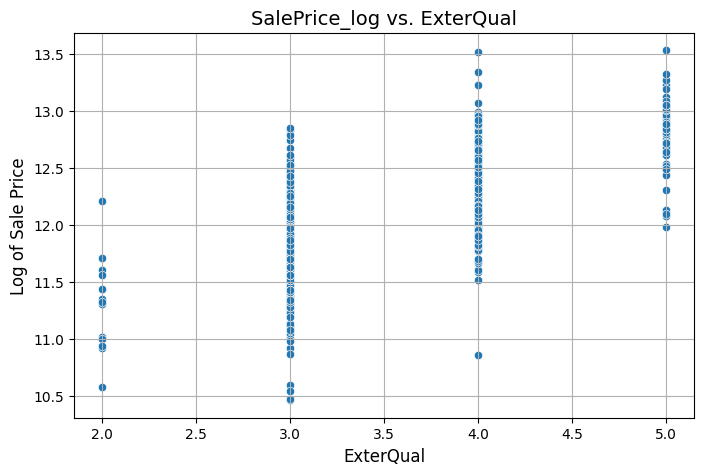

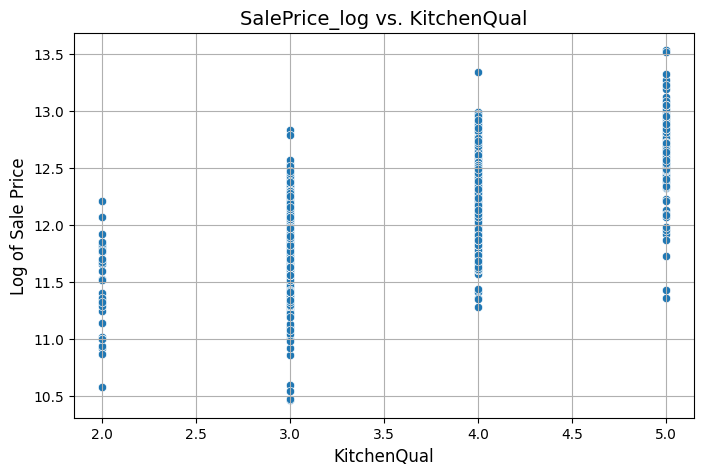

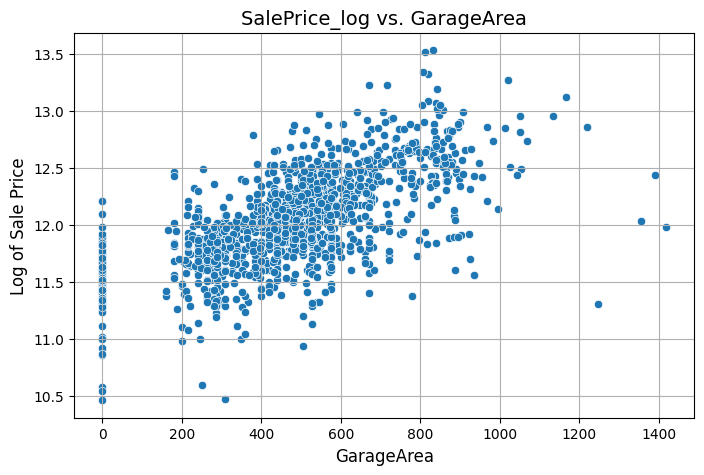

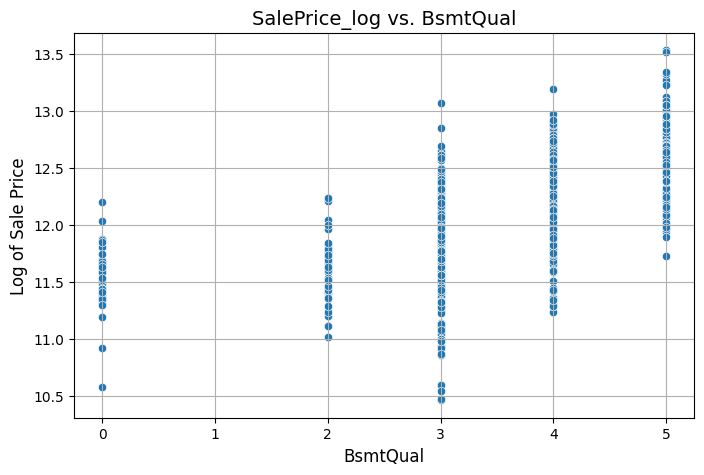

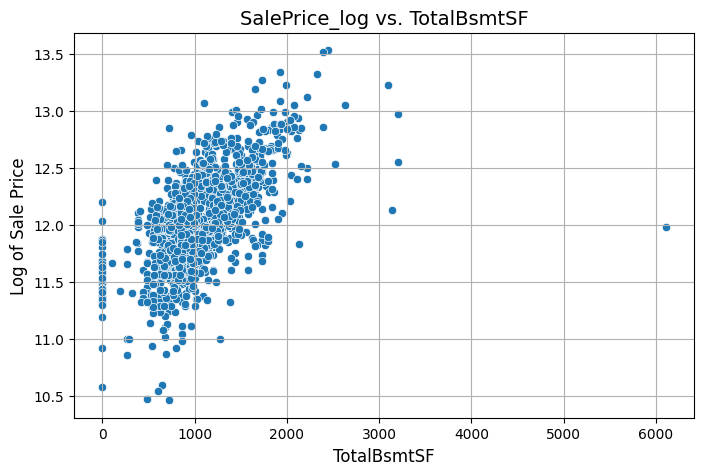

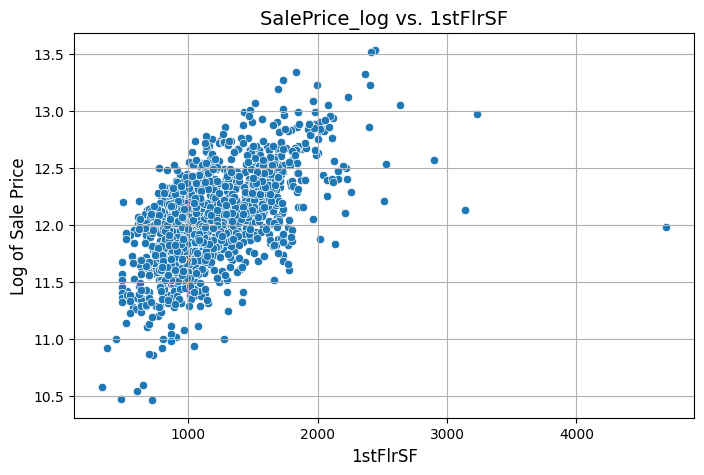

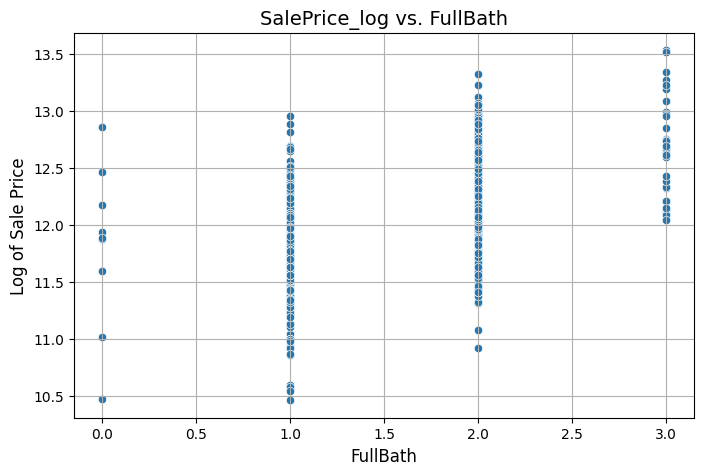

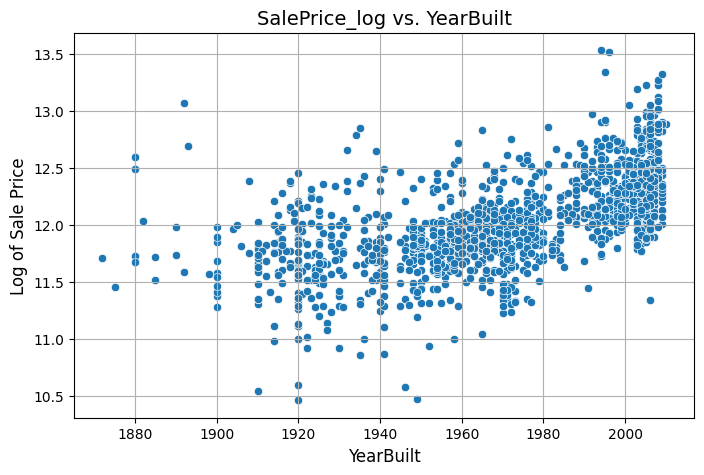

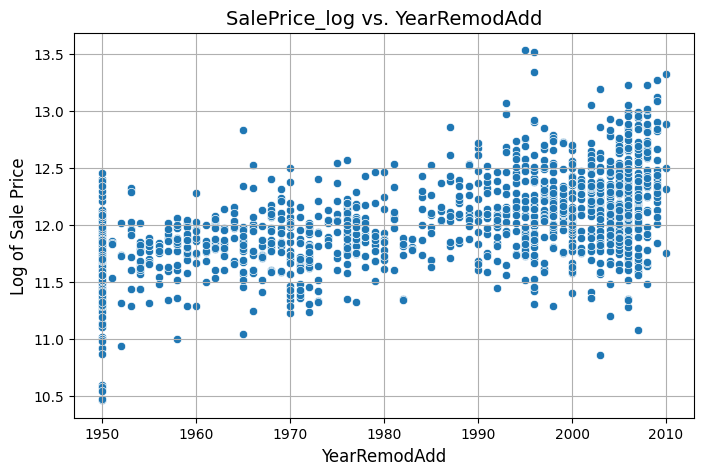

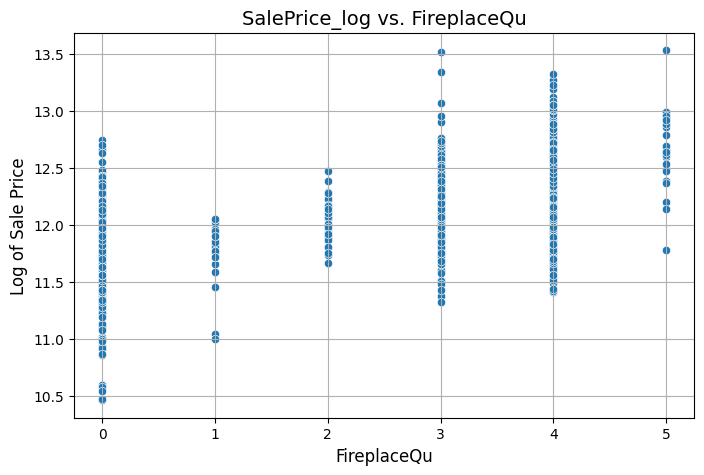

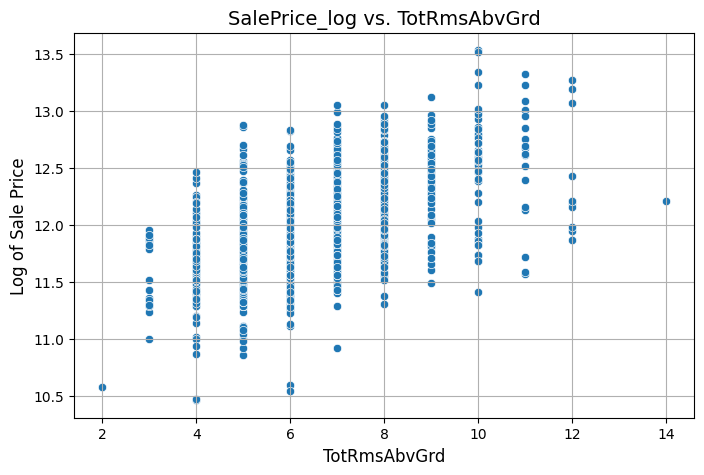

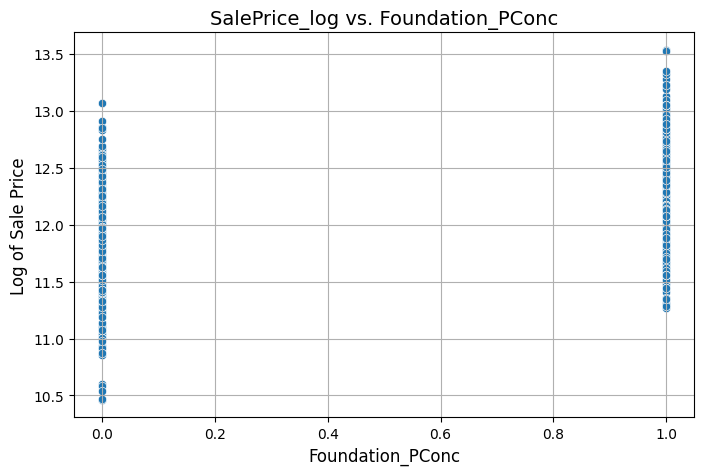

In [15]:
# List of the most important features we identified
features_to_plot = ['OverallQual','GrLivArea','GarageCars',
                    'ExterQual','KitchenQual','GarageArea',
                    'BsmtQual','TotalBsmtSF','1stFlrSF',
                    'FullBath','YearBuilt','YearRemodAdd',
                    'FireplaceQu','TotRmsAbvGrd','Foundation_PConc']

# Create scatter plots for each feature against SalePrice_log
for feature in features_to_plot:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df[feature], y=df['SalePrice_log'])
    plt.title(f'SalePrice_log vs. {feature}', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Log of Sale Price', fontsize=12)
    plt.grid(True)
    plt.show()

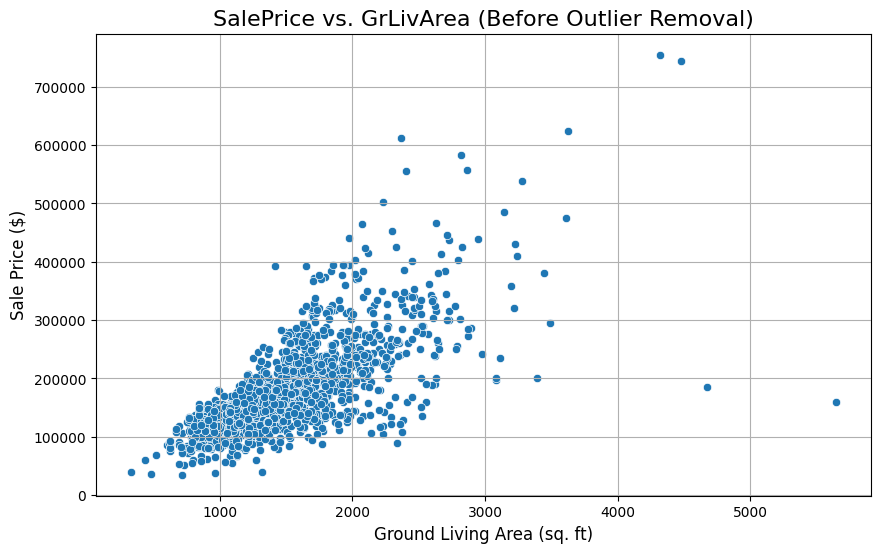

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title('SalePrice vs. GrLivArea (Before Outlier Removal)', fontsize=16)
plt.xlabel('Ground Living Area (sq. ft)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.grid(True)
plt.show()

In [17]:
# Print the original size of the DataFrame
print(f"Original number of rows: {df.shape[0]}")

# Remove the outliers by creating a new DataFrame
df = df[df['GrLivArea'] < 4000 ]
df = df[df['GrLivArea'] > 500 ]

# Print the new size of the DataFrame to confirm removal
print(f"Number of rows after removing outliers: {df.shape[0]}")

Original number of rows: 1460
Number of rows after removing outliers: 1453


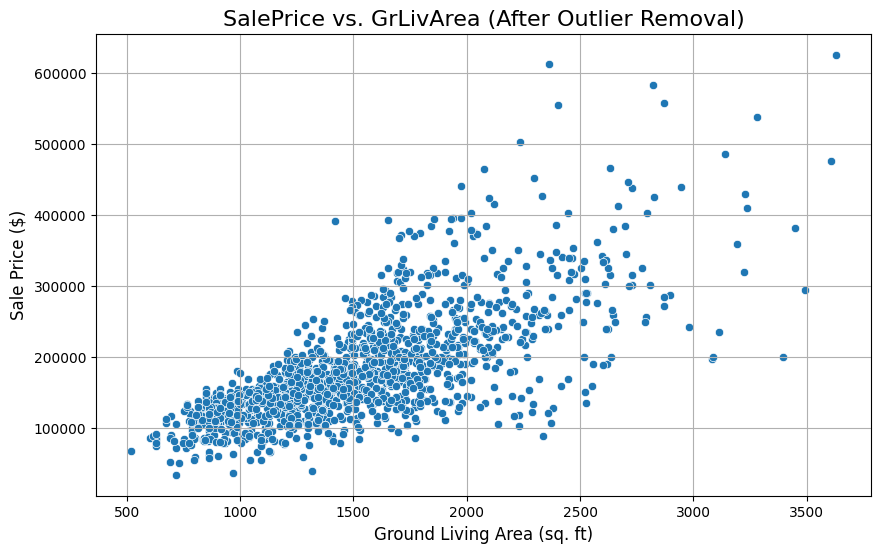

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title('SalePrice vs. GrLivArea (After Outlier Removal)', fontsize=16)
plt.xlabel('Ground Living Area (sq. ft)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.grid(True)
plt.show()

In [19]:
# Select only numerical columns for the correlation matrix
numerical_cols = df.select_dtypes(include=np.number)
correlations = numerical_cols.corr()

# Get the top 20 features most correlated with SalePrice (excluding SalePrice itself)
# We use .nlargest to get the top values from the 'SalePrice' column of the correlation matrix
k = 21 # number of variables for heatmap
top_corr_features = correlations.nlargest(k, 'SalePrice')['SalePrice'].index
print("--- Top 20 Features Correlated with SalePrice ---")
print(correlations['SalePrice'].nlargest(k))

--- Top 20 Features Correlated with SalePrice ---
SalePrice           1.000000
SalePrice_log       0.956871
OverallQual         0.800385
GrLivArea           0.718427
ExterQual           0.693797
KitchenQual         0.664535
GarageCars          0.647638
TotalBsmtSF         0.644275
GarageArea          0.635515
1stFlrSF            0.622543
BsmtQual            0.590981
FullBath            0.556698
TotRmsAbvGrd        0.534037
YearBuilt           0.533923
FireplaceQu         0.527435
YearRemodAdd        0.518483
Foundation_PConc    0.504669
MasVnrArea          0.473254
Fireplaces          0.465239
BsmtFinType1_GLQ    0.435688
HeatingQC           0.431984
Name: SalePrice, dtype: float64


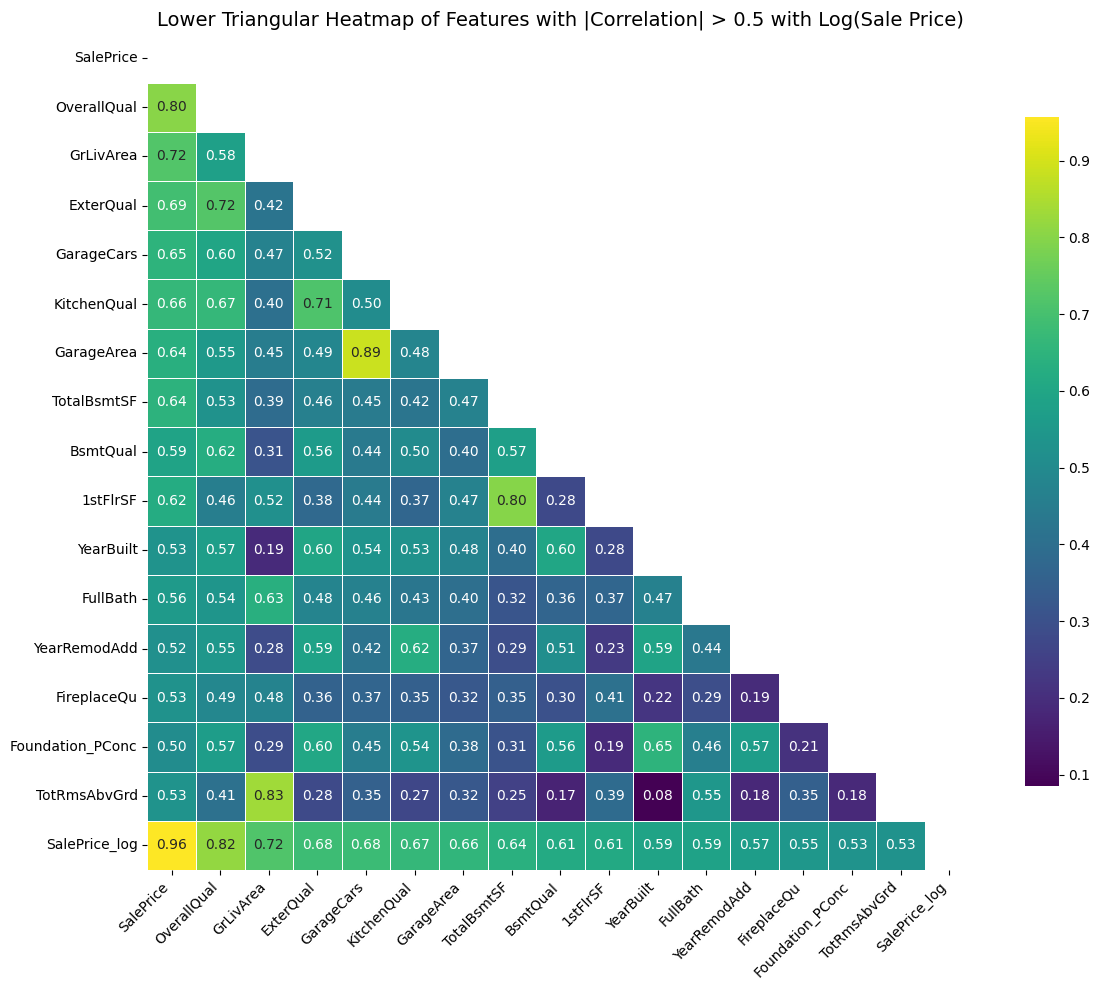

In [20]:
# --- 3. Correlation Filtering and Heatmap Plotting ---

# Calculate correlation with the target ('SalePrice_log')
corr_with_target = df.corr()['SalePrice_log'].sort_values(ascending=False)

# Identify features with absolute correlation > 0.5 (excluding SalePrice_log itself)
high_corr_features = corr_with_target[abs(corr_with_target) > 0.5].index.tolist()

# The target variable must be present in the list for the heatmap
if 'SalePrice_log' in high_corr_features:
    high_corr_features.remove('SalePrice_log')
features_for_heatmap = high_corr_features + ['SalePrice_log']

# Create the final correlation matrix for the selected features
corr_matrix_final = df[features_for_heatmap].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix_final, dtype=bool))

# Plot the lower triangular heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix_final,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Lower Triangular Heatmap of Features with |Correlation| > 0.5 with Log(Sale Price)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

We see strong positive correlations for features like:

* `OverallQual`: Overall material and finish quality.

* `GrLivArea`: Above grade (ground) living area square feet.

* `GarageCars`: Size of garage in car capacity.

* `GarageArea`: Size of garage in square feet.

* `TotalBsmtSF`: Total square feet of basement area.

The heatmap also reveals correlations between predictors. For instance, `GarageCars` and `GarageArea` are highly correlated (around 0.88). This is a strong sign of **multicollinearity**, which we'll need to address when building the model later. For now, in EDA, we just note it.

In [21]:
# Define the target variable (y)
y = df['SalePrice_log']

# Define the predictor variables (X) by dropping the target and its original version
X = df.drop(['SalePrice', 'SalePrice_log'], axis=1)

In [22]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1453 entries, 0 to 1459
Columns: 229 entries, MSSubClass to SaleCondition_Partial
dtypes: float64(229)
memory usage: 2.5 MB


In [23]:
# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be for testing, and 80% for training.
# random_state=42 ensures that we get the same split every time we run the code, for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1162 entries, 1065 to 1131
Columns: 229 entries, MSSubClass to SaleCondition_Partial
dtypes: float64(229)
memory usage: 2.0 MB


In [25]:
print("--- Data Shapes After Splitting ---")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

--- Data Shapes After Splitting ---
X_train shape: (1162, 229)
X_test shape: (291, 229)
y_train shape: (1162,)
y_test shape: (291,)


In [26]:
# Create an instance of the Linear Regression model
model = LinearRegression()

# Train (fit) the model on the training data
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [27]:
# Make predictions on the test data
y_pred = model.predict(X_test)

In [28]:
# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Performance on Test Set ---")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

--- Model Performance on Test Set ---
R-squared (R²): 0.9189
Root Mean Squared Error (RMSE): 0.1104


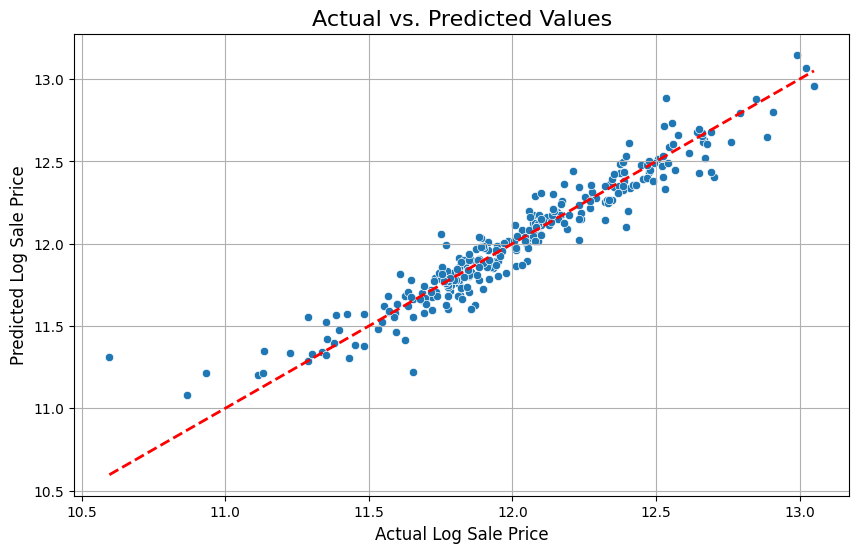

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
# Plotting a line for perfect predictions (y_test = y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.xlabel("Actual Log Sale Price", fontsize=12)
plt.ylabel("Predicted Log Sale Price", fontsize=12)
plt.title("Actual vs. Predicted Values", fontsize=16)
plt.grid(True)
plt.show()

In [30]:
# statsmodels requires us to manually add a constant (the intercept)
X_train_sm = sm.add_constant(X_train)

# Create and fit the model using statsmodels
sm_model = sm.OLS(y_train, X_train_sm).fit()

# Print the detailed summary
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:          SalePrice_log   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     73.22
Date:                Thu, 02 Oct 2025   Prob (F-statistic):               0.00
Time:                        17:36:59   Log-Likelihood:                 1118.3
No. Observations:                1162   AIC:                            -1797.
Df Residuals:                     942   BIC:                            -683.8
Df Model:                         219                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    10.42

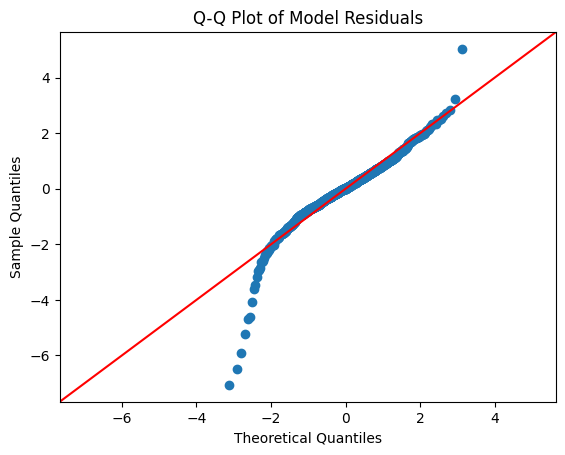

In [31]:
# Assuming 'model' is your fitted OLS model (as done in the Durbin-Watson step)
#model = sm.OLS(y, X).fit()

# Get the residuals from the model
residuals = sm_model.resid

# Create the Q-Q plot
fig = qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Model Residuals')
plt.show()

In [32]:
from scipy.stats import shapiro
# Assuming 'residuals' is already defined from the fitted model

# Perform the Shapiro-Wilk test
stat, p_value = shapiro(residuals)

print(f"Shapiro-Wilk Test Statistic (W): {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Residuals are NOT normally distributed (Reject H0).")
else:
    print("Conclusion: Residuals are normally distributed (Fail to reject H0).")

Shapiro-Wilk Test Statistic (W): 0.9340
P-value: 0.0000
Conclusion: Residuals are NOT normally distributed (Reject H0).
